# Seminar 02: Computational Graph, Backprop, and Clean Training Loops

**Student Version**

Goals for today:
- Build intuition for the **computational graph** in PyTorch
- See how **backprop** flows through `.grad_fn`
- Use `Dataset` and `DataLoader` for **batch training**
- Write a **clean training loop** with train/val split and metrics
- Learn a practical debugging checklist for: it does not learn
- Compare optimizer and learning-rate choices through training curves


## 0. Setup

In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Helpers

In [2]:
def make_moons(n=1000, noise=0.12):
    # Simple moons generator without sklearn
    n0 = n // 2
    n1 = n - n0
    t0 = np.random.rand(n0) * np.pi
    t1 = np.random.rand(n1) * np.pi

    x0 = np.stack([np.cos(t0), np.sin(t0)], axis=1)
    x1 = np.stack([1 - np.cos(t1), 1 - np.sin(t1)], axis=1)

    X = np.concatenate([x0, x1], axis=0).astype(np.float32)
    y = np.concatenate([np.zeros(n0), np.ones(n1)], axis=0).astype(np.float32)

    X += np.random.randn(*X.shape).astype(np.float32) * noise

    idx = np.random.permutation(n)
    return X[idx], y[idx]

def plot_points(X, y, title='Dataset'):
    X = np.asarray(X)
    y = np.asarray(y)
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=y, s=12)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()

@torch.no_grad()
def accuracy_from_logits(logits, y_true):
    logits = logits.reshape(-1)
    preds = (torch.sigmoid(logits) >= 0.5).float()
    return (preds == y_true).float().mean().item()

@torch.no_grad()
def plot_decision_boundary(model, X, y, title='Decision boundary', grid_steps=220):
    model.eval()
    X_np = np.asarray(X, dtype=np.float32)
    y_np = np.asarray(y)
    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_steps),
        np.linspace(y_min, y_max, grid_steps),
    )
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)
    grid_t = torch.from_numpy(grid).to(next(model.parameters()).device)

    logits = model(grid_t).reshape(-1)
    probs = torch.sigmoid(logits).cpu().numpy()
    zz = probs.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, zz, levels=25)
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=12, edgecolors='k', linewidths=0.2)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()

## 1. Computational graph in PyTorch
PyTorch records operations on tensors to build a dynamic computational graph.

### Exercise 1.1
Create a scalar loss `L` from inputs `x` and `w`, then inspect:
- `L.grad_fn`
- a few nodes in `L.grad_fn.next_functions`

Then call `backward()` and verify gradients exist for leaf tensors.


In [3]:
# Exercise 1.1
x = torch.randn(3, requires_grad=True)
w = torch.randn(3, requires_grad=True)

# TODO: define L = ((x * w).sum())**2
L = ((x * w).sum())**2
# TODO: print L, L.grad_fn
print(L, L.grad_fn)
# TODO: print a couple of next_functions entries
print(L.grad_fn.next_functions)

# TODO: call backward
L.backward()
# TODO: print x.grad and w.grad
print(x.grad)
print(w.grad)

#raise NotImplementedError("Fill in Exercise 1.1")

tensor(0.0123, grad_fn=<PowBackward0>) <PowBackward0 object at 0x7ff61279b9a0>
((<SumBackward0 object at 0x7ff612faa6e0>, 0),)
tensor([-0.0510,  0.2488,  0.0413])
tensor([-0.0746, -0.0285, -0.0519])


### Checks (Exercise 1.1)

In [4]:
assert x.grad is not None and w.grad is not None
assert x.grad.shape == x.shape and w.grad.shape == w.shape
print('Exercise 1.1 passed.')

Exercise 1.1 passed.


## 2. Backprop sanity check (manual vs autograd)
We will compare a simple manual derivative with autograd.

### Exercise 2.1
Let `a` be a scalar. Define:
$f(a) = (3a + 2)^2$

Compute `df/da` manually and compare with autograd.


In [5]:
# Exercise 2.1
a = torch.tensor(1.5, requires_grad=True)

# TODO: f = (3*a + 2)**2
f = (3*a + 2)**2
# TODO: f.backward()
f.backward()
# TODO: grad_auto = a.grad.item()
grad_auto = a.grad.item()

# TODO: grad_manual (write the formula and compute the number)
grad_manual = 18*a + 12

# TODO: print both and compare
print(grad_auto, grad_manual)

# raise NotImplementedError("Fill in Exercise 2.1")

39.0 tensor(39., grad_fn=<AddBackward0>)


### Checks (Exercise 2.1)

In [6]:
assert abs(grad_auto - grad_manual) < 1e-6
print('Exercise 2.1 passed.')

Exercise 2.1 passed.


## 3. Batch training with Dataset and DataLoader

### Exercise 3.1
Create a custom `Dataset` for a moons dataset.

Requirements:
- `__len__` returns N
- `__getitem__` returns `(x, y)` where `x` has shape `(2,)` and `y` is a float scalar 0 or 1

Then create:
- train/val split (80/20)
- `DataLoader` with batching and shuffling for train
- `DataLoader` without shuffling for val


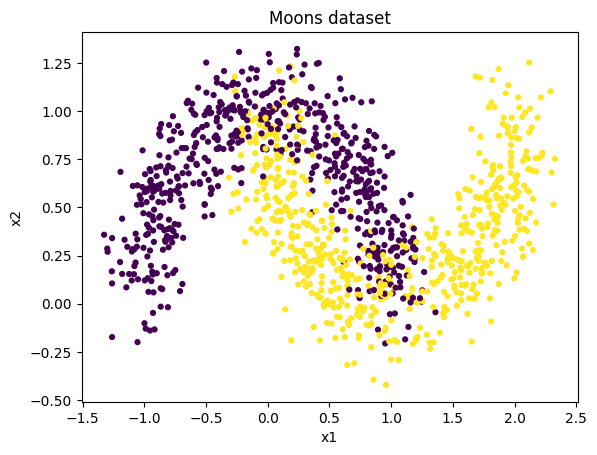

In [7]:
# Data for Exercise 3.1
seed_everything(10)
X_np, y_np = make_moons(n=1200, noise=0.15)
plot_points(X_np, y_np, title='Moons dataset')

In [9]:
# Exercise 3.1

class MoonsDataset(Dataset):
    def __init__(self, X, y):
        # TODO: store data as torch tensors

        # self.X: float32 tensor [N, 2]
        # self.y: float32 tensor [N]
        self.x = torch.from_numpy(X).to(device)
        self.y = torch.from_numpy(y).to(device)

    def __len__(self):
        # TODO
        return self.x.shape[0]

    def __getitem__(self, idx):
        # TODO: return (x_i, y_i)
        return (self.x[idx], self.y[idx])

# TODO: create dataset
dataset = MoonsDataset(X_np, y_np)
# TODO: split indices into train and val
n = len(dataset)
# TODO: create train_ds and val_ds
# train_ds = dataset[torch.randn(n)]
index = torch.randperm(n)
# train_ds = dataset[index[:int(n*0.8)]]
# val_ds = dataset[index[int(n*0.8):]]

train_ds = torch.utils.data.Subset(dataset, index[:int(n*0.8)])
val_ds = torch.utils.data.Subset(dataset, index[int(n*0.8):])

# TODO: create DataLoaders

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)


# raise NotImplementedError("Fill in Exercise 3.1")

### Checks (Exercise 3.1)

In [10]:
batch_x, batch_y = next(iter(train_loader))
print('batch_x:', batch_x.shape, batch_x.dtype)
print('batch_y:', batch_y.shape, batch_y.dtype)

assert batch_x.ndim == 2 and batch_x.shape[1] == 2
assert batch_y.ndim == 1
assert batch_x.dtype == torch.float32 and batch_y.dtype == torch.float32
print('Exercise 3.1 passed.')

batch_x: torch.Size([64, 2]) torch.float32
batch_y: torch.Size([64]) torch.float32
Exercise 3.1 passed.


## 4. Write a clean training loop (train/val, metrics)

We will train a small MLP on the moons dataset.

### Exercise 4.1
Implement two functions:
- `train_one_epoch(model, loader, opt, loss_fn)`
- `evaluate(model, loader, loss_fn)`

Both should return `(avg_loss, avg_accuracy)`.

Rules:
- In `evaluate`, use `model.eval()` and `torch.no_grad()`
- In training, use `model.train()`
- Move batches to `device`


In [11]:
# Model and config for Exercise 4.1
model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
).to(device)

loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.02)

Epoch 01 | train loss 0.5351 acc 0.714 | val loss 0.5103 acc 0.738
Epoch 05 | train loss 0.4028 acc 0.800 | val loss 0.3941 acc 0.833
Epoch 10 | train loss 0.2483 acc 0.910 | val loss 0.2881 acc 0.871
Epoch 15 | train loss 0.2195 acc 0.904 | val loss 0.2769 acc 0.887
Epoch 20 | train loss 0.2065 acc 0.911 | val loss 0.2694 acc 0.875
Epoch 25 | train loss 0.2091 acc 0.908 | val loss 0.2829 acc 0.846
Epoch 30 | train loss 0.2041 acc 0.903 | val loss 0.2664 acc 0.900


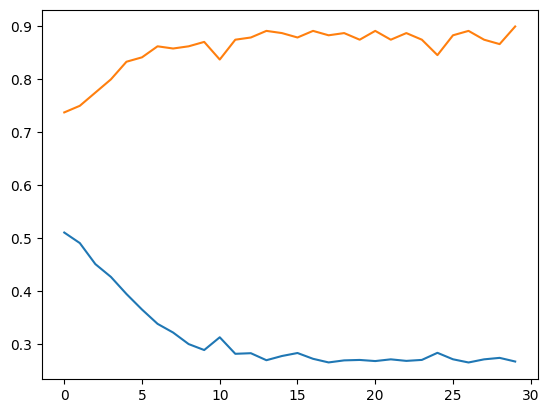

In [12]:
# Exercise 4.1

def train_one_epoch(model, loader, opt, loss_fn):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for xb, yb in loader:
        # TODO: move to device
        xb_t = xb.to(device)
        yb_t = yb.to(device)
        # TODO: forward -> logits
        y_hat = model(xb_t)
        y_hat = y_hat.reshape(-1)
        # TODO: loss
        loss = loss_fn(y_hat, yb_t)
        # TODO: backward + step + zero_grad
        loss.backward()

        opt.step()

        opt.zero_grad()

        # TODO: compute batch accuracy
        train_acc = accuracy_from_logits(y_hat.detach(), yb_t)

        # TODO: accumulate weighted by batch size
        total_loss += loss * xb_t.shape[0]
        total_acc += train_acc * xb_t.shape[0]
        total_n += xb_t.shape[0]

    # TODO: return avg loss and avg acc
    return total_loss/total_n, total_acc/total_n

def evaluate(model, loader, loss_fn):
    # TODO: eval mode + no_grad
    model.eval()
    with torch.no_grad():
        total_loss = 0.0
        total_acc = 0.0
        total_n = 0

        for xb, yb in loader:
            xb_t = xb.to(device)
            yb_t = yb.to(device)

            y_hat = model(xb_t)
            y_hat = y_hat.reshape(-1)

            # TODO: loss
            loss = loss_fn(y_hat, yb_t)
            # TODO: backward + step + zero_grad
            # loss.backward()
            # opt.zero_grad()
            opt.step()

            # TODO: compute batch accuracy
            train_acc = accuracy_from_logits(y_hat, yb_t)

            # TODO: accumulate weighted by batch size
            total_loss += loss * xb_t.shape[0]
            total_acc += train_acc * xb_t.shape[0]
            total_n += xb_t.shape[0]

        return total_loss/total_n, total_acc/total_n

    # return avg loss and avg acc
    # raise NotImplementedError


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
epochs = 30

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, opt, loss_fn)
    va_loss, va_acc = evaluate(model, val_loader, loss_fn)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}')

# TODO: plot loss and accuracy curves
plt.plot(history['val_loss'])
plt.plot(history["val_acc"])
plt.show()

# raise NotImplementedError("Fill in Exercise 4.1")

### Optional: visualize decision boundary

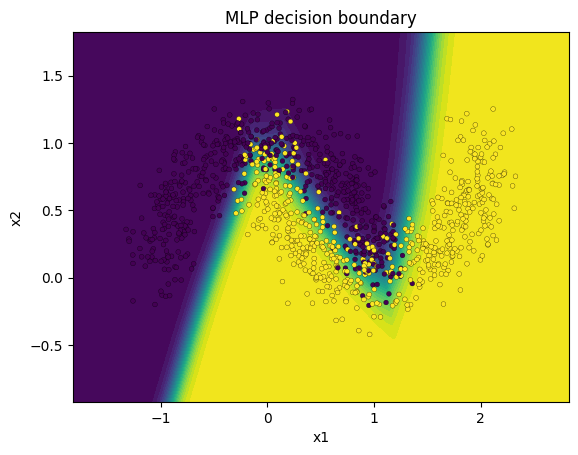

In [13]:
plot_decision_boundary(model, X_np, y_np, title='MLP decision boundary')

## 5. Extra practice: optimizers, learning rates, and failure modes

The clean training loop is the main product of this seminar. If you finish early, use this section to test how training behavior changes when you change the optimizer or learning rate.

Goal: stop treating `optimizer` and `lr` as magic words. Look at curves and diagnose behavior.


### Exercise 5.1: compare optimizers and learning rates

Run the same model with several optimizer settings.

Suggested configurations:
- SGD, `lr=0.1`
- SGD, `lr=0.01`
- Adam, `lr=0.02`
- Adam, `lr=0.002`

Tasks:
- Write `make_model()` so every experiment starts from a fresh model
- Write `run_training_experiment(...)` that returns a history dictionary
- Plot validation accuracy curves on one figure
- Print the final validation accuracy for each run

Question: which setting learns fastest, and which setting is most stable?


   sgd_lr_0.1 | final val acc=0.779 | final val loss=0.4633
  sgd_lr_0.01 | final val acc=0.721 | final val loss=0.5427
 adam_lr_0.02 | final val acc=0.850 | final val loss=0.2791
adam_lr_0.002 | final val acc=0.775 | final val loss=0.4574


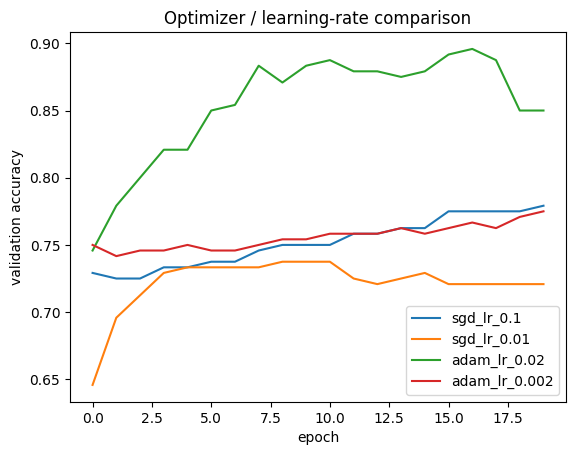

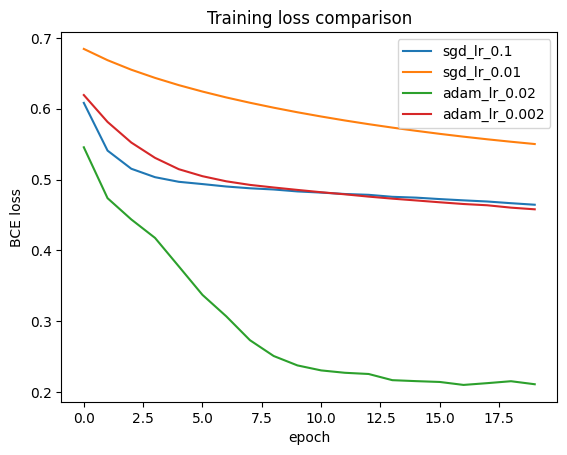

In [15]:
from binascii import Error
# Exercise 5.1

def make_model(hidden_dim=32):
    x = nn.Sequential(
        nn.Linear(2, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 1),
    ).to(device)

    return x

def make_optimizer(model, optimizer_name, lr):
    # TODO: support "sgd" and "adam"
    if optimizer_name == "sgd":
      sgd = torch.optim.SGD(params=model.parameters(), lr=lr)
      return sgd
    elif optimizer_name == "adam":
      admm = torch.optim.Adam(params=model.parameters(), lr=lr)
      return admm
    else:
      raise Exception("...")

def run_training_experiment(name, optimizer_name, lr, epochs=20):
    # TODO: seed, create model/loss/optimizer, train, evaluate each epoch
    # TODO: return a dictionary with name, model, and history
    exp_model = make_model()
    exp_loss_fn = nn.BCEWithLogitsLoss()
    exp_opt = make_optimizer(model=exp_model, optimizer_name=optimizer_name, lr=lr)
    exp_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for i in range(epochs):
      tr_loss, tr_acc = train_one_epoch(exp_model, train_loader, exp_opt, exp_loss_fn)
      va_loss, va_acc = evaluate(exp_model, val_loader, exp_loss_fn)
      exp_history["train_loss"].append(tr_loss.detach().numpy())
      exp_history["train_acc"].append(tr_acc)
      exp_history["val_loss"].append(va_loss.detach().numpy())
      exp_history["val_acc"].append(va_acc)

    return {
        "name": name,
        "model": exp_model,
        "optimizer": optimizer_name,
        "lr": lr,
        "history": exp_history,
    }


experiment_configs = [
    ("sgd_lr_0.1", "sgd", 0.1),
    ("sgd_lr_0.01", "sgd", 0.01),
    ("adam_lr_0.02", "adam", 0.02),
    ("adam_lr_0.002", "adam", 0.002),
]

experiment_results = [
    run_training_experiment(name, optimizer_name, lr)
    for name, optimizer_name, lr in experiment_configs
]

for row in experiment_results:
    print(f"{row['name']:>13} | final val acc={row['history']['val_acc'][-1]:.3f} | final val loss={row['history']['val_loss'][-1]:.4f}")

plt.figure()
for row in experiment_results:
    plt.plot(row["history"]["val_acc"], label=row["name"])
plt.title("Optimizer / learning-rate comparison")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.legend()
plt.show()

plt.figure()
for row in experiment_results:
    plt.plot(row["history"]["train_loss"], label=row["name"])
plt.title("Training loss comparison")
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.legend()
plt.show()


In [ ]:
exit(0)

### Checks (Exercise 5.1)


In [ ]:
assert len(experiment_results) == len(experiment_configs)
assert all("history" in row and "val_acc" in row["history"] for row in experiment_results)
assert max(row["history"]["val_acc"][-1] for row in experiment_results) > 0.75
print("Exercise 5.1 checks passed.")


### Exercise 5.2: failed training diagnosis lab

Create two intentionally broken runs and describe their symptoms.

Required broken runs:
- **No optimizer step:** compute gradients but do not call `opt.step()`
- **Learning rate too small:** use a very small learning rate such as `1e-5`

Tasks:
- Reuse your training-loop code where possible
- Plot or print the curves
- Write 1-2 sentences for each run: what symptom did you see, and what would you check first?


In [ ]:
# Exercise 5.2

# TODO: implement a short run where loss.backward() happens but opt.step() does not
# TODO: run a second experiment with lr=1e-5
# TODO: compare both against a healthy run

raise NotImplementedError("Fill in Exercise 5.2")


## 6. Debugging checklist: it does not learn

When your model does not learn, check these in this order:

1) **Data and labels**
   - Are labels correct? Any label leakage?
   - Are you mixing up shapes: logits `[B]` vs targets `[B]`?

2) **Loss and activation mismatch**
   - For binary classification: prefer `BCEWithLogitsLoss` with raw logits (no sigmoid in model)

3) **Gradients and optimizer**
   - Did you call `loss.backward()`?
   - Did you call `opt.step()`?
   - Did you call `opt.zero_grad()`?

4) **Learning rate**
   - Too small: nothing changes
   - Too large: loss explodes or becomes `nan`

5) **Train vs eval mode**
   - `model.train()` in training, `model.eval()` in evaluation

### Mini task
Intentionally break one thing (for example comment out `opt.step()`), observe what happens, then fix it.
Write 2 sentences explaining the symptom and the fix.
